# Глава 3 — YOLOv12 (task_07)

Обучение YOLOv12-m на четырёх вариантах подготовки данных: `baseline` → `aug_geom` → `aug_oversample` → `aug_diffusion`.

Полный протокол: `code/docs/chapter3_protocol.md`. Скрипт-раннер: `chapter3_ultralytics_runner.py`.

Артефакты каждого запуска — в `code/results/task_07/yolov12_<variant>/`.

Тренинг запущен как фоновый процесс на сервере. Этот нотбук только **отображает прогресс**.

## 🔴 Живой монитор

Запустите ячейку `## Live monitor` ниже — она сама обновляется каждые 10 сек: хвост лога + мини-график mAP@50 по эпохам. Остановите Stop-кнопкой (квадрат на тулбаре), когда хотите дальше работать с нотбуком. Остальные ячейки — снимок состояния (перезапускайте по ходу).

## 0. Конфигурация и импорты

In [2]:
import os
import json
import time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, clear_output, HTML

ROOT = Path('/home/vanusha/diplom/diploma-plant-disease')
TASK_DIR = ROOT / 'code/results/task_07'
VARIANTS = ['baseline', 'aug_geom', 'aug_oversample', 'aug_diffusion']
LOG_FILE = Path('/tmp/train_yolov12.log')
print('Task dir:', TASK_DIR)
print('Live log:', LOG_FILE)

Task dir: /home/vanusha/diplom/diploma-plant-disease/code/results/task_07
Live log: /tmp/train_yolov12.log


## 1. Запуск обучения (все 4 варианта)

Уже запущено из терминала:

```bash
PY=/home/vanusha/.pyenv/versions/3.12.10/envs/diplom/bin/python
$PY code/notebooks/chapter3_ultralytics_runner.py --detector yolov12 --variant all > /tmp/train_yolov12.log 2>&1 &
```

## 🔴 Live monitor

Обновляется каждые 10 сек. Остановите ячейку кнопкой Stop (■), когда хотите листать остальные.

[live 16:15:33]
      1/100      11.4G      2.029      4.453      2.184         63        640: 16% ━╸────────── 96/583 2.6it/s 44.4s<3:10
      1/100      11.4G      2.032      4.452      2.184         77        640: 17% ━╸────────── 97/583 2.6it/s 44.8s<3:09
      1/100      11.4G      2.029       4.44       2.18         53        640: 17% ━━────────── 98/583 2.6it/s 45.2s<3:09
      1/100      11.4G      2.027      4.437      2.178         50        640: 17% ━━────────── 99/583 2.5it/s 45.6s<3:12
      1/100      11.4G      2.025      4.431      2.175         94        640: 17% ━━────────── 100/583 2.5it/s 46.0s<3:11
      1/100      11.4G      2.028      4.423      2.174        108        640: 17% ━━────────── 101/583 2.5it/s 46.4s<3:14
      1/100      11.4G      2.027      4.413      2.173         67        640: 17% ━━────────── 102/583 2.3it/s 46.9s<3:25
      1/100      11.4G      2.026      4.407      2.171         50        640: 18% ━━────────── 103/583 2.3it/s 47.4s<3:29
    

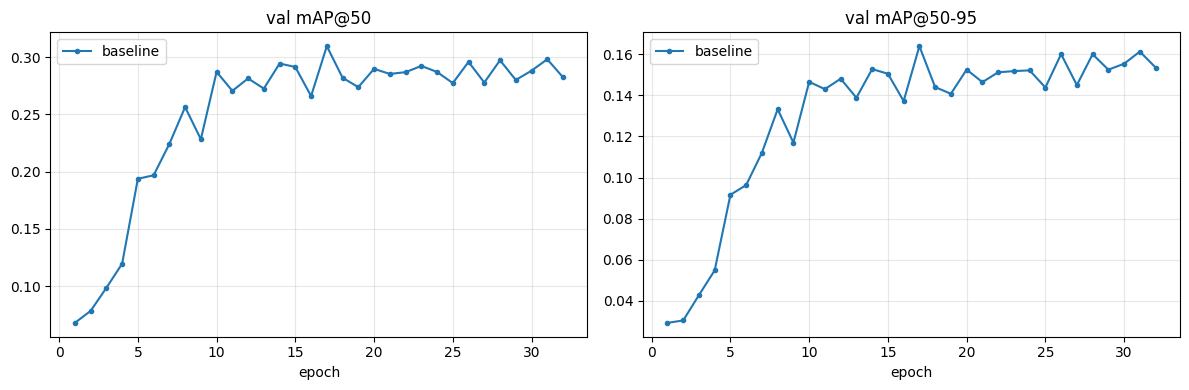

In [ ]:
import time
from IPython.display import clear_output

def find_current_variant():
    for v in reversed(VARIANTS):
        if (TASK_DIR / f'yolov12_{v}' / 'results.csv').exists():
            return v
    return None

try:
    while True:
        clear_output(wait=True)
        now = time.strftime('%H:%M:%S')
        print(f'[live {now}]')
        # Log tail
        if LOG_FILE.exists():
            lines = LOG_FILE.read_text(errors='ignore').splitlines()
            clean = [l for l in lines if l.strip() and 'K' != l[:1]]
            print('\n'.join(clean[-25:]))
        else:
            print('лог ещё не создан')
        # Metrics
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        any_data = False
        for v in VARIANTS:
            p = TASK_DIR / f'yolov12_{v}' / 'results.csv'
            if not p.exists():
                continue
            try:
                df = pd.read_csv(p)
                df.columns = [c.strip() for c in df.columns]
                if 'metrics/mAP50(B)' in df.columns:
                    axs[0].plot(df['epoch'], df['metrics/mAP50(B)'], label=v, marker='o', markersize=3)
                if 'metrics/mAP50-95(B)' in df.columns:
                    axs[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label=v, marker='o', markersize=3)
                any_data = True
            except Exception as e:
                pass
        if any_data:
            axs[0].set_title('val mAP@50'); axs[1].set_title('val mAP@50-95')
            for ax in axs:
                ax.set_xlabel('epoch'); ax.grid(True, alpha=0.3); ax.legend()
            plt.tight_layout(); plt.show()
        else:
            plt.close(fig)
        time.sleep(10)
except KeyboardInterrupt:
    print('\n[monitor stopped]')

## 2. Статический хвост лога (снимок)

In [ ]:
if LOG_FILE.exists():
    lines = LOG_FILE.read_text(errors='ignore').splitlines()
    print('\n'.join(lines[-40:]))
else:
    print('Обучение ещё не запущено или лог не создан.')

## 3. Метрики по вариантам (снимок)

In [ ]:
def load_metrics(variant: str) -> pd.DataFrame:
    p = TASK_DIR / f'yolov12_{variant}' / 'metrics.csv'
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for v in VARIANTS:
    df = load_metrics(v)
    if df.empty:
        continue
    axs[0].plot(df['epoch'], df['val_mAP50'], label=v)
    axs[1].plot(df['epoch'], df['val_mAP5095'], label=v)
for ax, title in zip(axs, ['val mAP@50', 'val mAP@50-95']):
    ax.set_xlabel('epoch')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Сводная таблица (после завершения всех вариантов)

In [ ]:
summary = TASK_DIR / 'summary.csv'
if summary.exists():
    df = pd.read_csv(summary)
    display(df)
else:
    print('summary.csv ещё не создан')

## 5. Learning curves каждого варианта

In [ ]:
for v in VARIANTS:
    p = TASK_DIR / f'yolov12_{v}' / 'learning_curves.png'
    if p.exists():
        print(f'=== {v} ===')
        display(Image(str(p)))

## 6. Confusion matrix каждого варианта

In [ ]:
for v in VARIANTS:
    p = TASK_DIR / f'yolov12_{v}' / 'confusion_matrix.png'
    if p.exists():
        print(f'=== {v} ===')
        display(Image(str(p)))

## 7. Качественные предсказания на фиксированной выборке

In [ ]:
qfile = ROOT / 'code/docs/chapter3_qualitative_sample.txt'
qnames = [l.strip() for l in qfile.read_text().splitlines() if l.strip() and not l.startswith('#')]
print('Fixed qualitative sample:', len(qnames))
for v in VARIANTS:
    folder = TASK_DIR / f'yolov12_{v}' / 'predictions_examples'
    if not folder.exists():
        continue
    print(f'\n=== {v} ===')
    for n in qnames[:4]:
        fp = folder / n
        if fp.exists():
            display(Image(str(fp), width=500))